In [1]:
%pip install -U gymnasium[atari] AutoROM ale-py stable-baselines3[extra] -q
# %%python -m AutoROM --accept-license
# %AutoROM --accept-license

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import base64
import cv2
import numpy as np
import ale_py
import gymnasium as gym
import torch
import warnings

from pathlib import Path
from IPython import display as ipythondisplay
from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv, VecVideoRecorder, VecFrameStack
from gymnasium.wrappers import ResizeObservation, GrayscaleObservation, TransformObservation
from stable_baselines3.common.atari_wrappers import AtariWrapper
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [3]:
class Environment():

  def __init__(self):
    self.env = gym.make("ALE/Breakout-v5", render_mode='rgb_array')
    self.env = AtariWrapper(self.env)
    self.env = ResizeObservation(self.env, shape=(84, 84,))
    self.env = TransformObservation(self.env, lambda obs: obs[:, :, np.newaxis], observation_space = self.env.observation_space)

In [4]:
class Model():

  def __init__(self, env):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model_ppo = PPO(policy = "CnnPolicy",
                    env = env,
                    verbose = 1,
                    tensorboard_log = "log",
                    device = device
                  )

    model_dqn = DQN(policy = "CnnPolicy",
                    env = env,
                    verbose = 1,
                    tensorboard_log = "log",
                    device = device
                  )

    model_a2c = A2C(policy = "CnnPolicy",
                    env = env,
                    verbose = 1,
                    tensorboard_log = "log",
                    device = device
                  )

    self.model = [
                  {"PPO": model_ppo},
                  {"DQN": model_dqn},
                  {"A2C": model_a2c}
                ]


In [5]:
from typing import List

class Video():

  def init(self):
    os.system("Xvfb :1 -screen 0 1024x768x24 &")
    os.environ['DISPLAY'] = ':1'


  def play(self, path = "videos/", prefixes=["breakout"]):
    html = []

    for prefix in prefixes:
      for mp4 in Path(path).glob("{}*.mp4".format(prefix)):
        video_b64 = base64.b64encode(mp4.read_bytes())
        html.append(
            """
              <video alt="{}" autoplay loop controls style="height: 400px;">
                  <source src="data:video/mp4;base64,{}" type="video/mp4" />
              </video>
            """.format(mp4, video_b64.decode("ascii")
          )
        )
    ipythondisplay.display(ipythondisplay.HTML(data="<br />".join(html)))


  def record(self, model, env, length = 500, prefix = "breakout", folder = "videos/"):
    dummy_environment = DummyVecEnv([lambda: env])

    video_environment = VecVideoRecorder(
      dummy_environment,
      video_folder = folder,
      record_video_trigger = lambda step: step == 0,
      video_length = length,
      name_prefix = prefix
    )

    obs = video_environment.reset()

    for _ in range(length):
      action, _ = model.predict(obs)
      obs, _, _, _ = video_environment.step(action)

    video_environment.close()


  def render(self, models: List[str], timesteps = [100000, 500000]):
    for model in models:
      for timestep in timesteps:
        print(f"\nRendering for {model} and {timestep} timesteps...")
        self.play(path = "videos/", prefixes = f"{model}_breakout_{timestep}_eval")

In [6]:
class Execution():

  def __init__(self, models, timesteps = [100000, 500000]) -> None:
    self.models = models
    self.timesteps = timesteps
    self.rewards = {}


  def chart(self):
    file_name = ""
    plt.figure()

    for model, values in self.rewards.items():
        reward_timesteps = sorted(values.keys())
        rewards_per_model = [values[t] for t in reward_timesteps]
        plt.plot(reward_timesteps, rewards_per_model, marker='o', linestyle='-', label=model)
        file_name = f"{model}_breakout_{rewards_per_model}"

    plt.xlabel("Timesteps")
    plt.ylabel("Reward")
    plt.title("Agent Score Evolution")
    plt.legend()
    plt.grid()
    plt.savefig(f"{file_name}.png")
    plt.show()


  def update_rewards(self, model_key, timestep, mean_reward, std_reward):
    if not hasattr(self, "rewards"):
        self.rewards = {}

    if model_key not in self.rewards:
        self.rewards[model_key] = {}

    self.rewards[model_key][timestep] = mean_reward

    print(f"\n\nAverage reward after {timestep} timesteps: {mean_reward:.2f} +/- {std_reward:.2f}")

    print(self.rewards)
    self.chart()


  def train(self, env):
    for model_dict in self.models:
      model_key = list(model_dict.keys())[0]
      print(f"\n\nTraining for {model_key}...")
      model = model_dict[model_key]

      for timestep in self.timesteps:
        print(f"\nTraining for {timestep} timesteps...\n")

        model.learn(total_timesteps = timestep,
                    log_interval = 10,
                    progress_bar = True)

        model.save(f"{model_key}_breakout_{timestep}")

        mean_reward, std_reward = evaluate_policy(model,
                                                  env,
                                                  n_eval_episodes = 5)

        self.update_rewards(model_key, timestep, mean_reward, std_reward)


  def eval(self, env, video):
    for model_dict in self.models:
      model_key = list(model_dict.keys())[0]
      print(f"\n\nEvaluating for {model_key}...")
      model = model_dict[model_key]

      for timestep in self.timesteps:
        print(f"\nEvaluating for {timestep} timesteps...\n")

        model = model.load(f"{model_key}_breakout_{timestep}", env = env)

        mean_reward, std_reward = evaluate_policy(model,
                                                  env,
                                                  n_eval_episodes = 5,
                                                  deterministic = False)

        self.update_rewards(model_key, timestep, mean_reward, std_reward)
        video.record(model = model,
                     env = env,
                     length = 500,
                     prefix = f"{model_key}_breakout_{timestep}_eval"
                    )


  def reset(self, envs):
    for env in envs:

      for model in self.models:
        del model

      env.close()

In [7]:
train_env = Environment().env
eval_env = Environment().env
models = Model(train_env).model
exec = Execution(models, timesteps = [100000, 500000, 1000000])
video = Video()

A.L.E: Arcade Learning Environment (version 0.10.1+unknown)
[Powered by Stella]


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.




Training for PPO...

Training for 100000 timesteps...

Logging to log/PPO_1


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 18.9        |
|    ep_rew_mean          | 1.5         |
| time/                   |             |
|    fps                  | 271         |
|    iterations           | 10          |
|    time_elapsed         | 75          |
|    total_timesteps      | 20480       |
| train/                  |             |
|    approx_kl            | 0.020418696 |
|    clip_fraction        | 0.201       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.13       |
|    explained_variance   | 0.74        |
|    learning_rate        | 0.0003      |
|    loss                 | -0.00521    |
|    n_updates            | 90          |
|    policy_gradient_loss | -0.0351     |
|    value_loss           | 0.152       |
-----------------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 23.8    



Average reward after 100000 timesteps: 2.80 +/- 2.04
{'PPO': {100000: 2.8}}


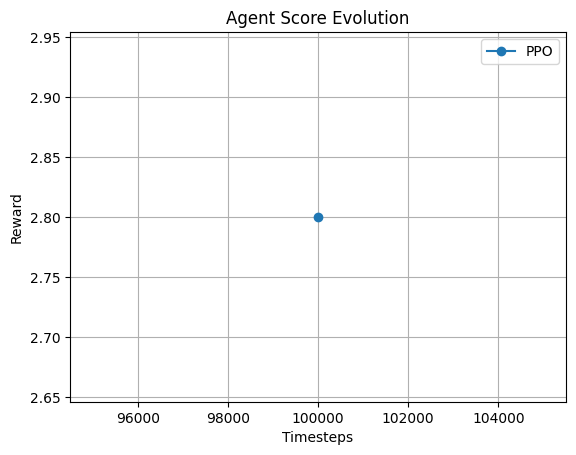


Training for 500000 timesteps...

Logging to log/PPO_2
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 25.5       |
|    ep_rew_mean          | 2.21       |
| time/                   |            |
|    fps                  | 290        |
|    iterations           | 10         |
|    time_elapsed         | 70         |
|    total_timesteps      | 20480      |
| train/                  |            |
|    approx_kl            | 0.10166824 |
|    clip_fraction        | 0.39       |
|    clip_range           | 0.2        |
|    entropy_loss         | -0.686     |
|    explained_variance   | 0.743      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.0197    |
|    n_updates            | 580        |
|    policy_gradient_loss | -0.0624    |
|    value_loss           | 0.158      |
----------------------------------------
----------------------------------------
| rollout/                |            |
|

In [ ]:
exec.train(train_env)

In [ ]:
exec.eval(eval_env, video)

In [ ]:
models_name = [list(model_dict.keys())[0] for model_dict in models]
video.render(models = models_name, timesteps = exec.timesteps)

In [ ]:
exec.reset([train_env, eval_env])